# BlueSky-Gym results visualizer

Created on 06/2026

Pyhton 3.13.5
Jupiter Kernel ipy3.13-bluesky-gym-plotter

@author: Giulia Leto, giuliam.leto@gmail.com

#### Create a Jupiter kernel for the environment
The lines of code below create a Jupyter kernel named ipy3.13-bluesky-gym-plotter that uses the Python interpreter from py3.13-bluesky-gym-plotter.

In [17]:
# !conda activate py3.13-bluesky-gym-plotter

# !pip install ipykernel
# !python -m ipykernel install --user --name=ipy3.13-bluesky-gym-plotter --display-name "ipy3.13-bluesky-gym-plotter"

#### Packages

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# BlueSky-Gym style plots

#### Function for setting custom ticks for the plots in scientific notation

In [19]:
def set_scientific_xticks(max_val, n_ticks=6, fontsize=25):
    step = max_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(step))
    step = np.round(step / magnitude) * magnitude
    ticks = np.arange(0, max_val + step, step)
    labels = ['0' if t == 0 else f'{t:.0e}'.replace('e+0', 'e') for t in ticks]
    plt.xticks(ticks, labels, fontsize=fontsize)


#### Function for calculating the moving average

In [20]:

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

#### Functions for making, showing and saving the plots

In [21]:
def make_plots(env, models, feature, labels, ave_window, input_folder, stride=30):
    """Makes the plot for a single feature across all models for the specified environment.
    Since the plot is a moving average, the stride (30 for example) can be used to reduce the 
    number of points plotted, while maintaining the curve (especially for saving PDFs, which 
    will be slow to load when the amount of plotted points is large) Use Stride = 1 to keep all points.
    """
    sns.set_theme(style="darkgrid")
    sns.set_context("talk")

    fig = plt.figure(figsize=(12, 9))
    plt.gca().spines[['right', 'top']].set_visible(False)

    max_timesteps = 0
    for model in models:
        y_data = pd.read_csv(f'{input_folder}{env}_{model}.csv')
        x_vals = y_data['timesteps'][:-(ave_window - 1)][::stride]
        y_vals = moving_average(y_data[feature], ave_window)[::stride]
        max_timesteps = max(max_timesteps, y_data['timesteps'].max())

        plt.plot(x_vals, y_vals, label=model, rasterized=True)

    # Set specific ticks and font size
    set_scientific_xticks(max_timesteps)
    plt.yticks(fontsize=25)
    plt.xlabel('Timesteps', fontsize=25)
    plt.ylabel(labels[feature], fontsize=25)

    # Adjust legend: larger font size and position in bottom-right corner
    legend = plt.legend(fontsize=18, loc='lower right', frameon=True)
    legend.get_frame().set_facecolor('white') # White background
    # legend.get_frame().set_edgecolor('black')  # Optional: black border

    plt.tight_layout()
    return fig


def show_plots(fig):
    """Displays the figure inline."""
    plt.show()


def save_plots(fig, env, models, feature, output_folder):
    """Saves the figure to a PDF file."""
    os.makedirs(output_folder, exist_ok=True)
    all_models = "_".join(models)
    output_filename = f"{env}_{all_models}-results_{feature}.pdf"
    output_path = os.path.join(output_folder, output_filename)

    fig.savefig(output_path, format='pdf', dpi=150)
    print(f"Plot saved as {output_path}")


#### Set the labels for all possible features that can be plotted

In [22]:
labels = {
    'waypoint_reached': 'Waypoint Reached',
    'total_reward': 'Total Reward',
    'crashed': 'Crashed',
    'average_drift': 'Average Drift',
    'total_intrusion_time': 'Total Intrusion Time',
    'intrusion_counter': 'Intrusion Counter',
    'reach_reward': 'Reach Reward',
    'drift_reward': 'Drift Reward',
    'intrusion_other_ac_reward': 'Intrusion Other AC Reward',
    'intrusion_reward': 'Intrusion Reward',
    'average_hdg_action': 'Average Heading Action',
    'average_spd_action': 'Average Speed Action',
    'hdg_action_saturated_rate': 'Heading Action Saturated Rate',
    'spd_action_saturated_rate': 'Speed Action Saturated Rate',
    'average_hdg_action_delta': 'Average Heading Action Delta',
    'average_spd_action_delta': 'Average Speed Action Delta',
    'hdg_reversal_rate': 'Heading Reversal Rate',
    'spd_reversal_rate': 'Speed Reversal Rate',
    'min_cpa': 'Minimum CPA',
    'num_encounters': 'Number of Encounters',
    'min_obstacle_distance': 'Minimum Obstacle Distance',
    'num_obstacle_encounters': 'Number of Obstacle Encounters',
    'extra_path_length': 'Extra Path Length',
    'path_length_ratio': 'Path Length Ratio',
    'actual_path_length': 'Actual Path Length',
    'planned_path_length': 'Planned Path Length',
    'planned_path_time': 'Planned Path Time'
}

# Making the plots for the latest saved logs

all available models are (this is the order used for the BlueSky-Gym paper)

["PPO", "SAC", "TD3", "DDPG"] 

#### Available features for 'StaticObstacleCR'

['total_reward', 'waypoint_reached', 'crashed', 'average_drift', 'total_intrusion_time', 'intrusion_counter', 'reach_reward', 'drift_reward', 'intrusion_other_ac_reward', 'intrusion_reward', 'average_hdg_action', 'average_spd_action', 'hdg_action_saturated_rate', 'spd_action_saturated_rate', 'average_hdg_action_delta', 'average_spd_action_delta', 'hdg_reversal_rate', 'spd_reversal_rate', 'min_cpa', 'num_encounters', 'min_obstacle_distance', 'num_obstacle_encounters', 'extra_path_length', 'path_length_ratio', 'actual_path_length', 'planned_path_length', 'planned_path_time']


/var/folders/81/_rhr4tyd4258cpp06hxkh3k40000gr/T/ipykernel_8078/4045854224.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(12, 9))


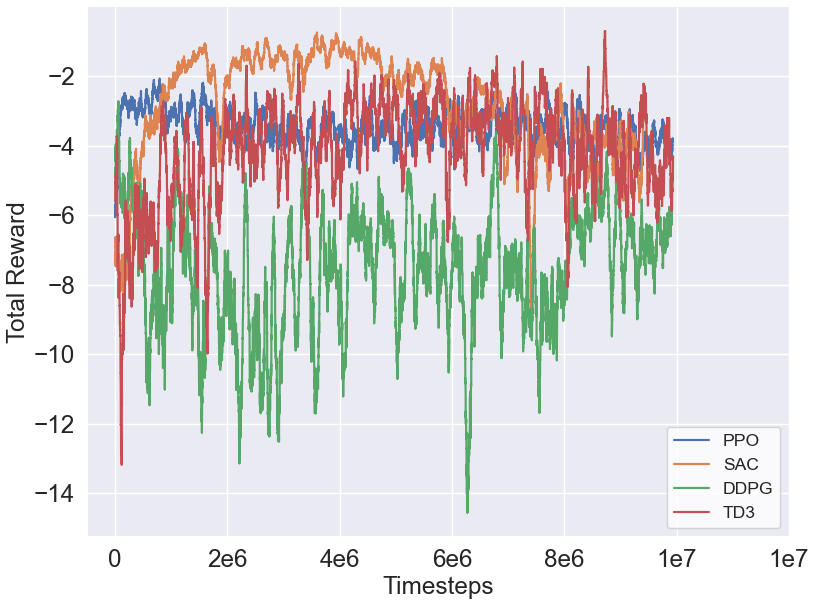

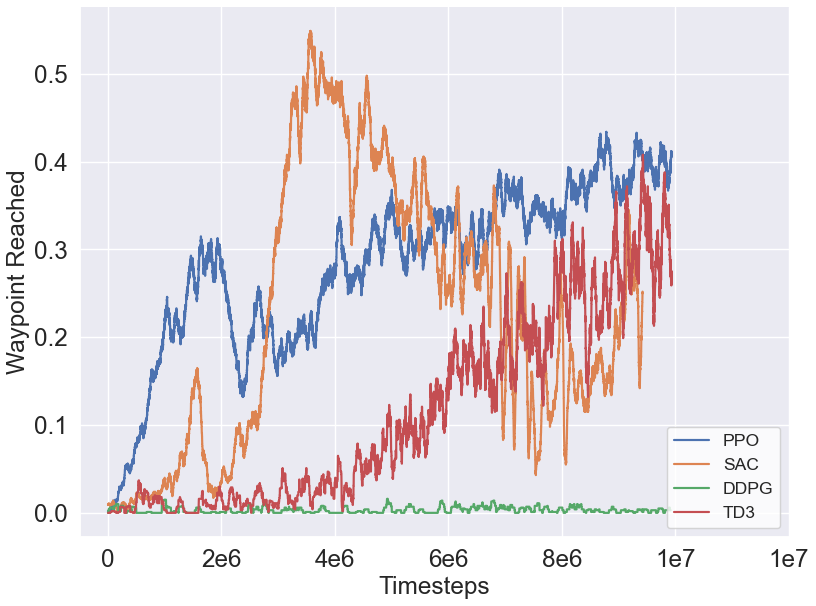

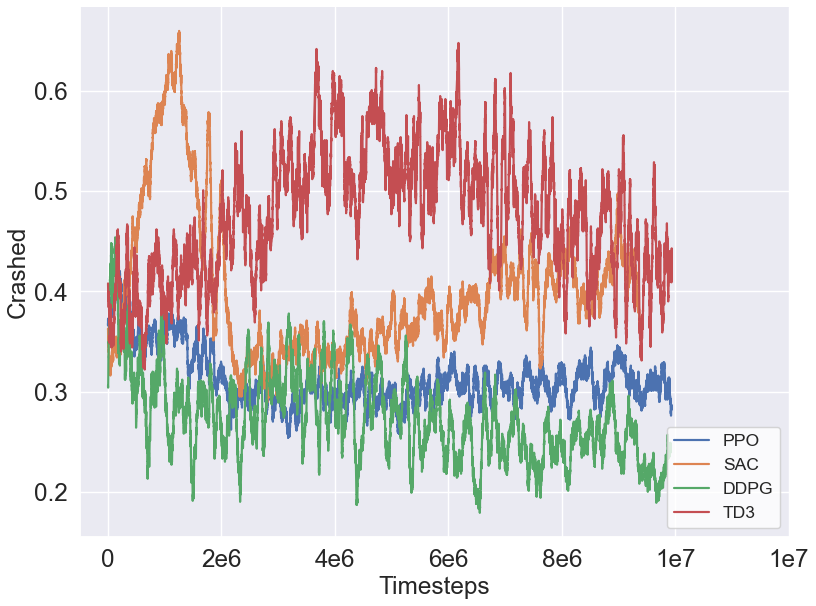

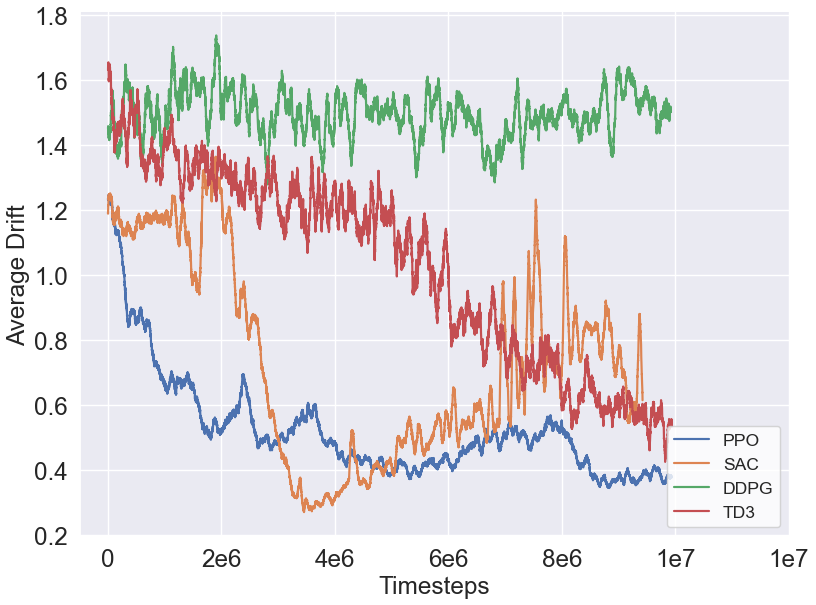

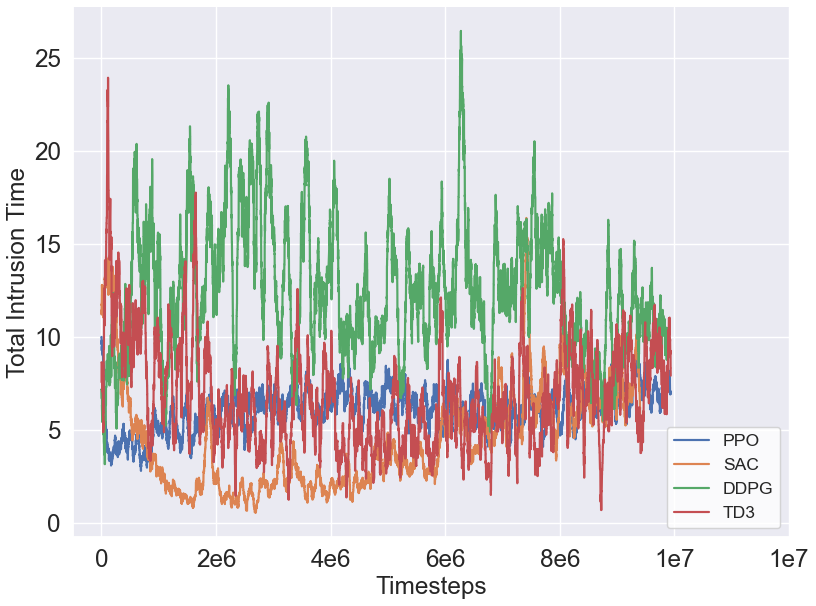

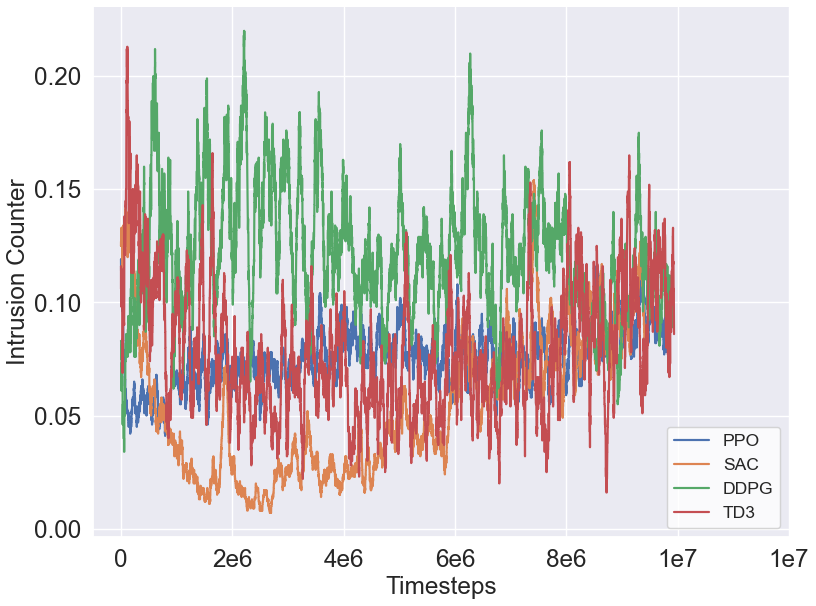

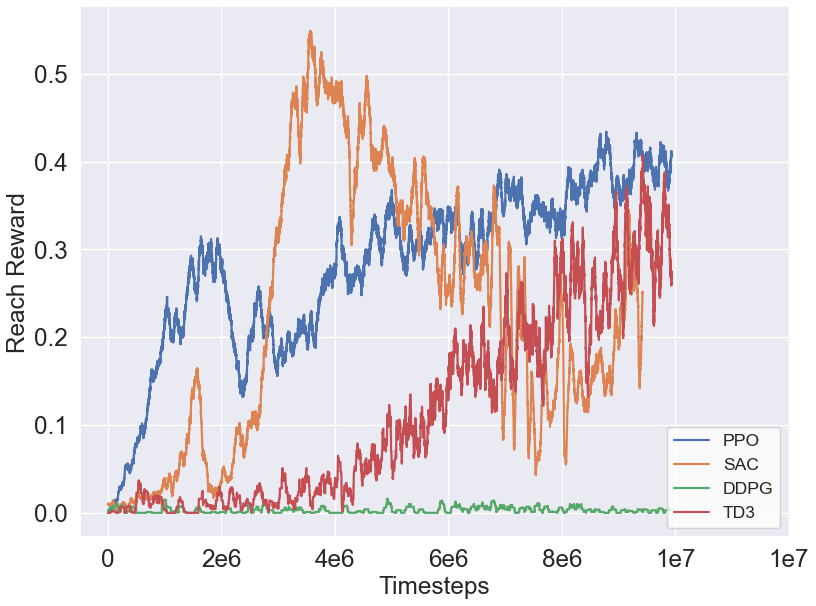

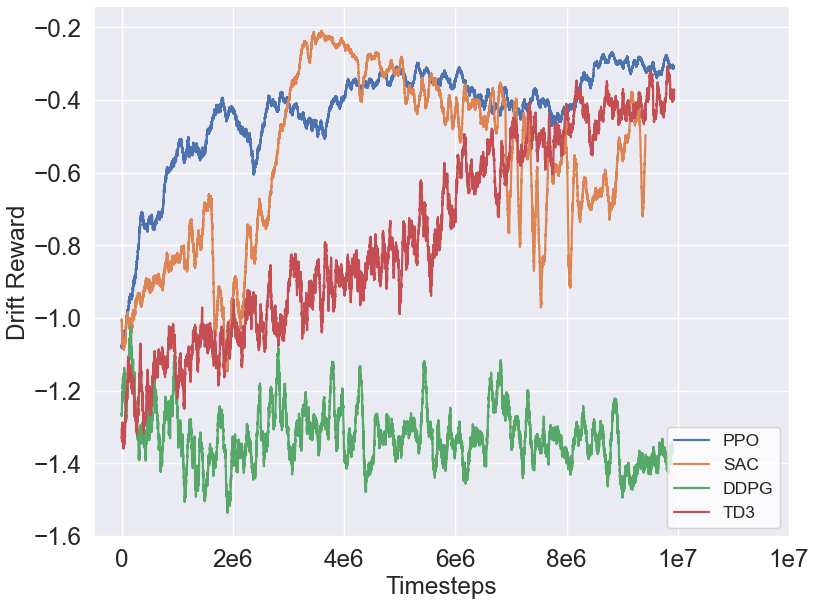

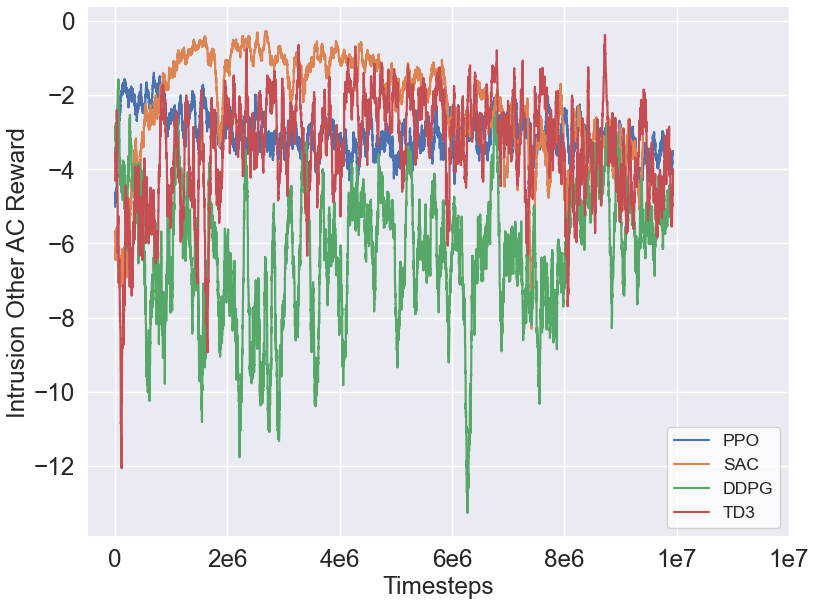

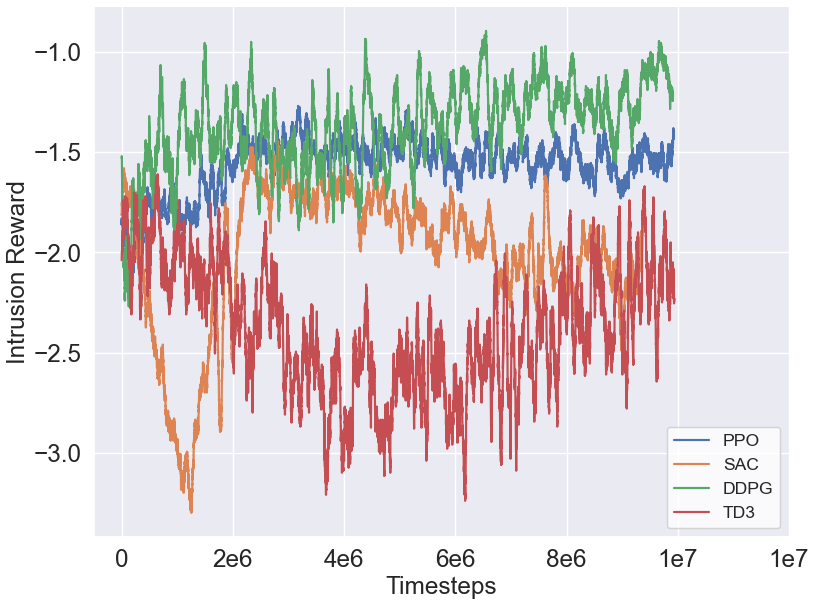

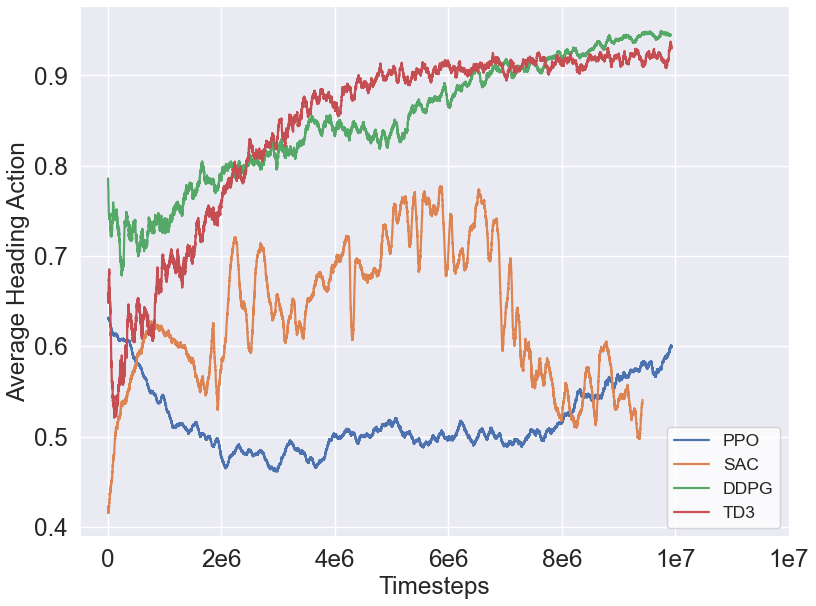

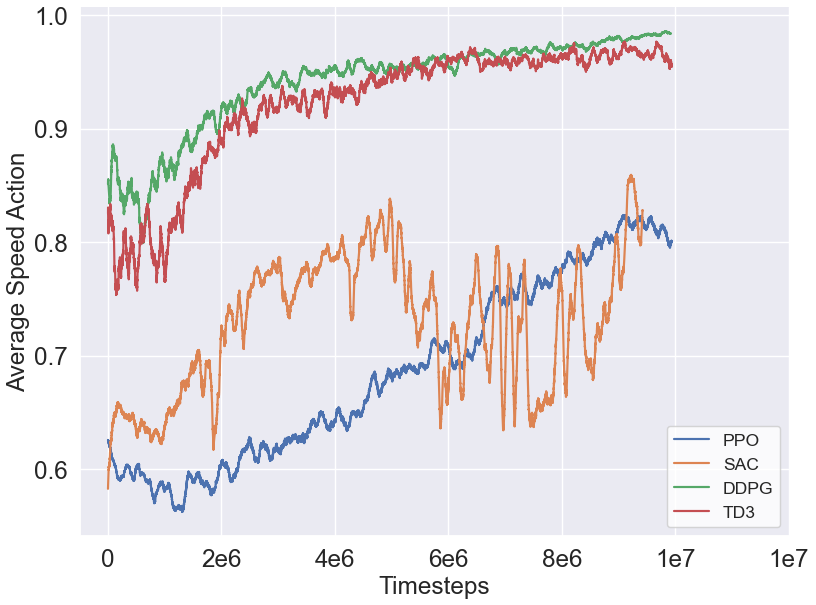

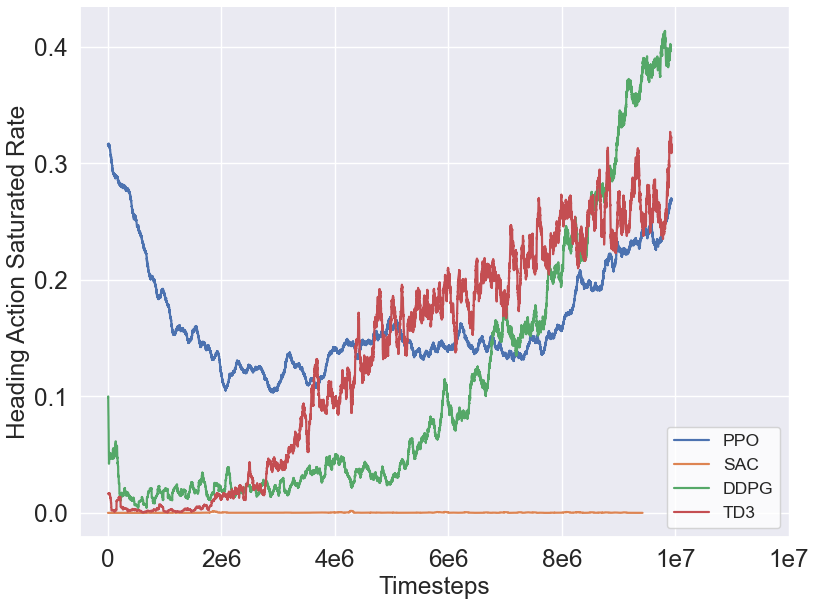

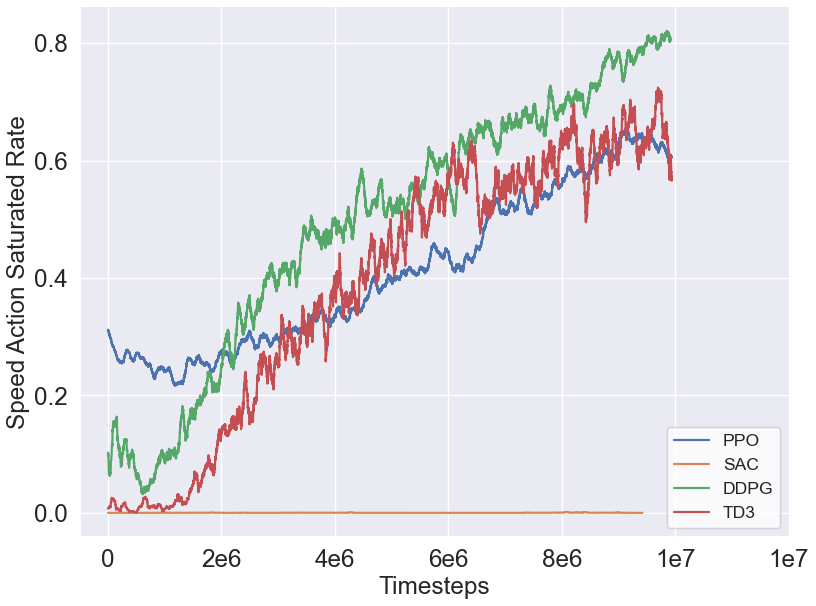

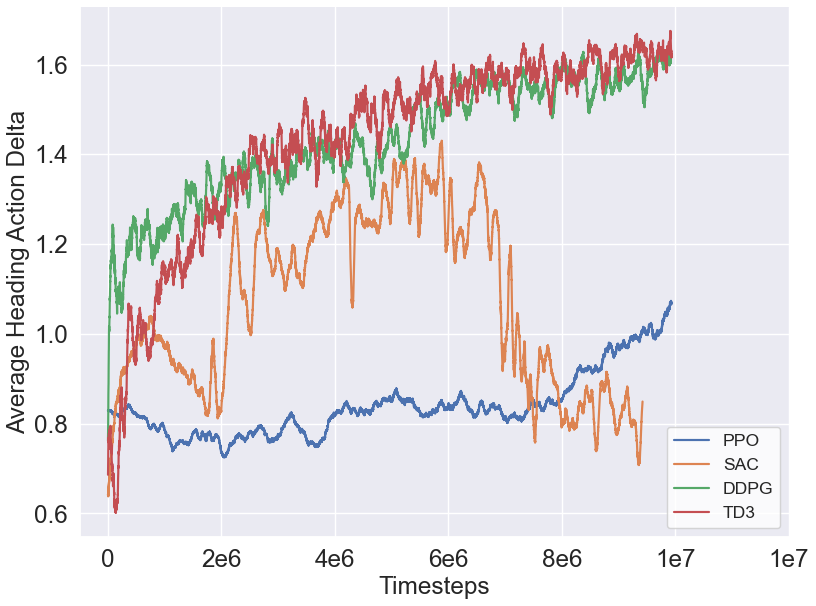

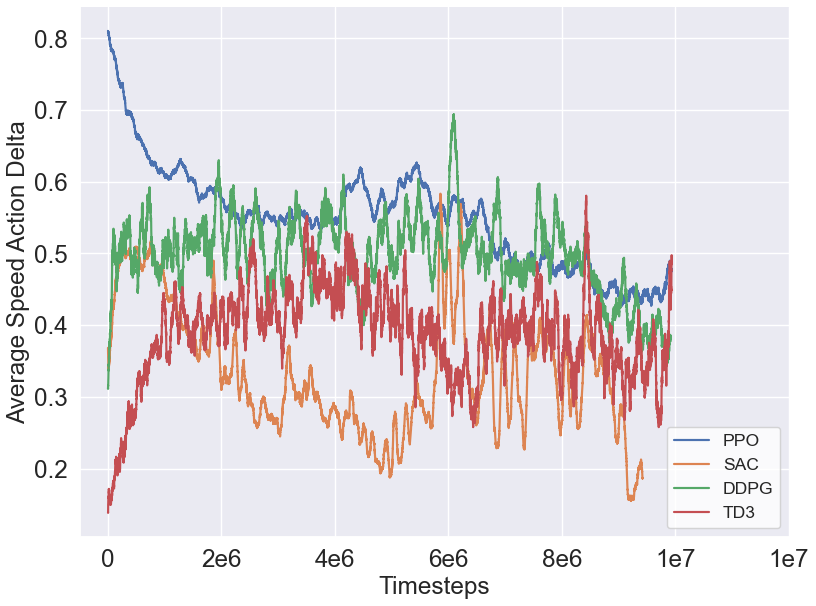

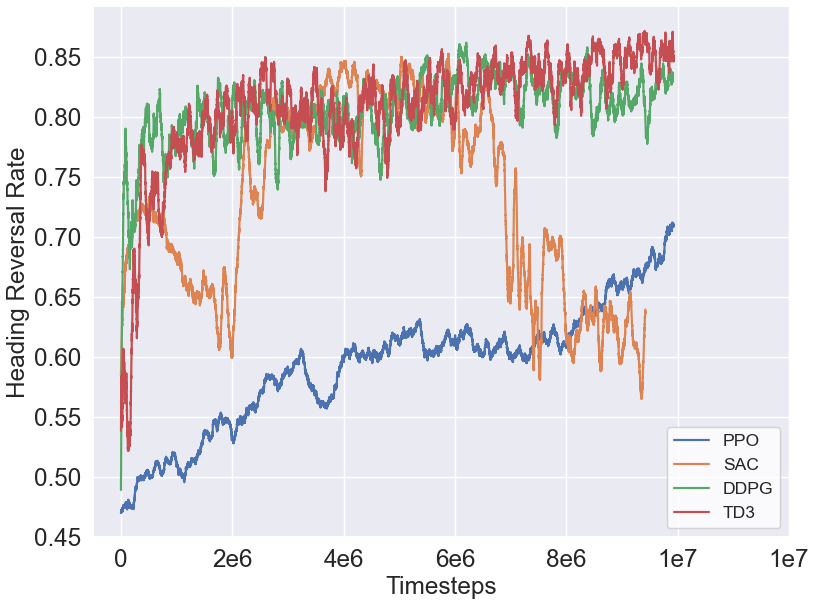

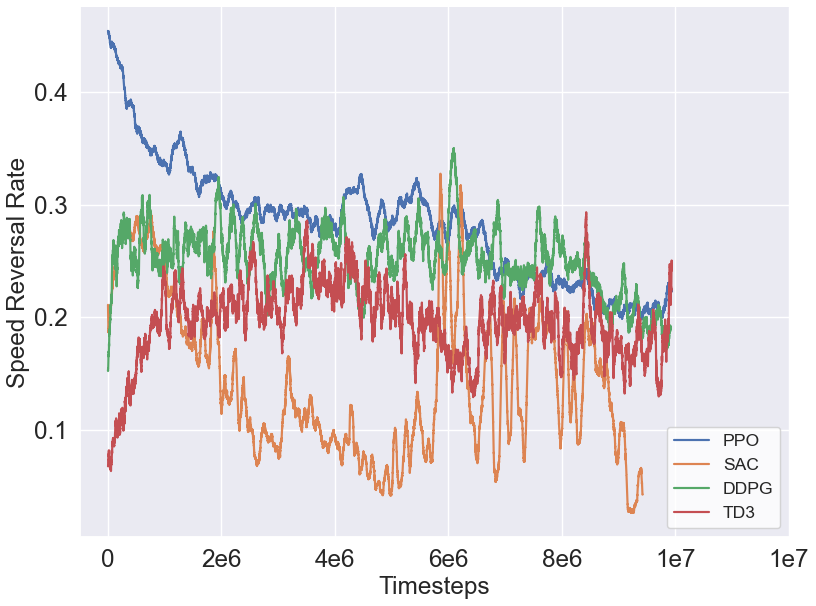

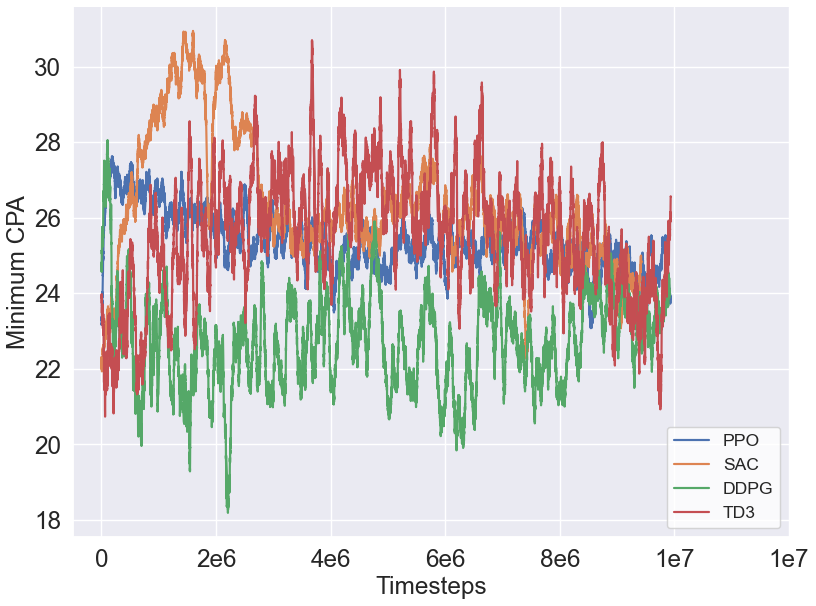

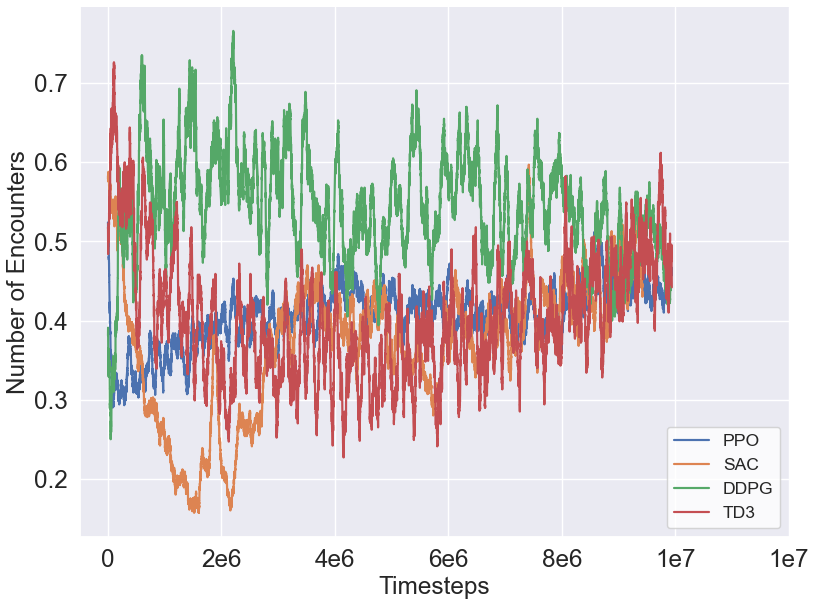

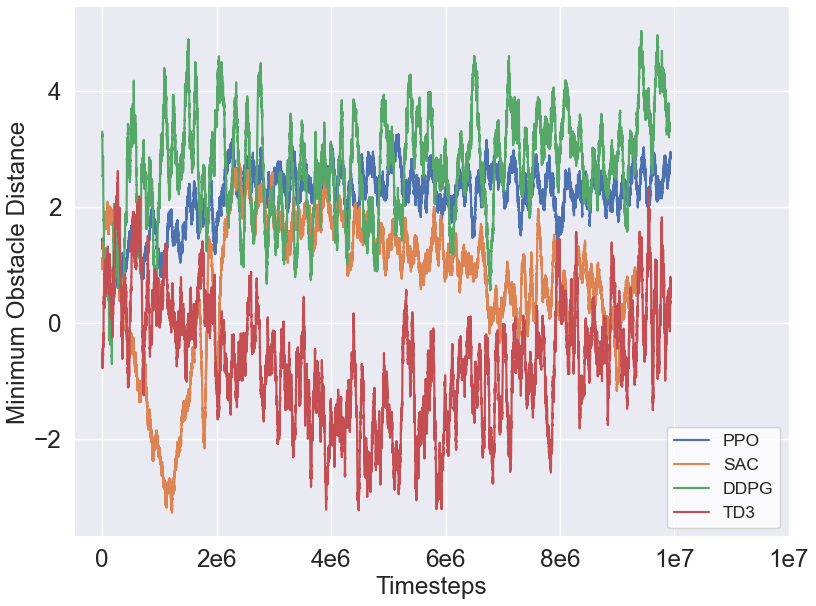

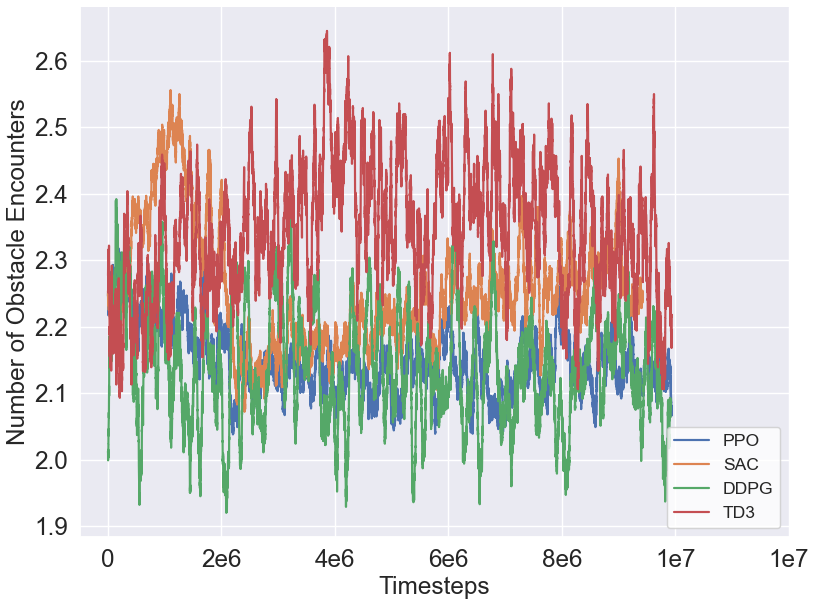

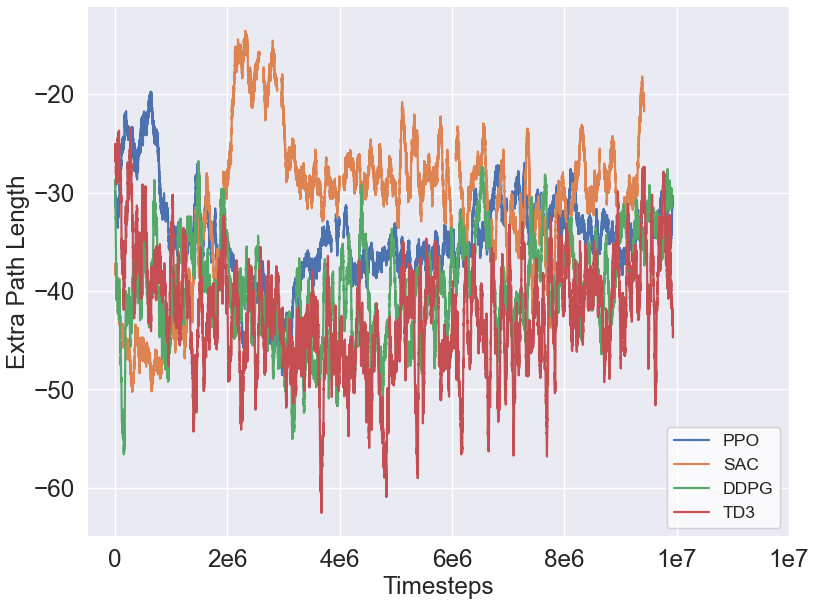

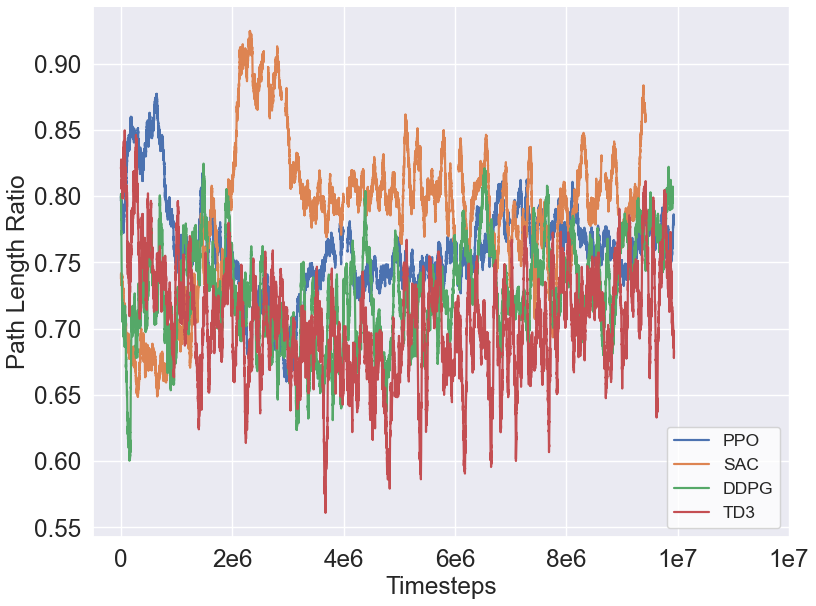

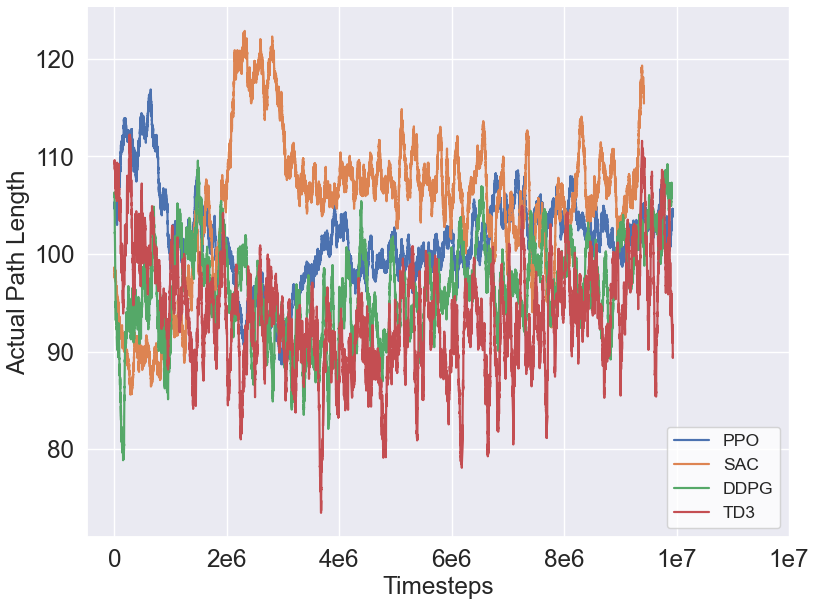

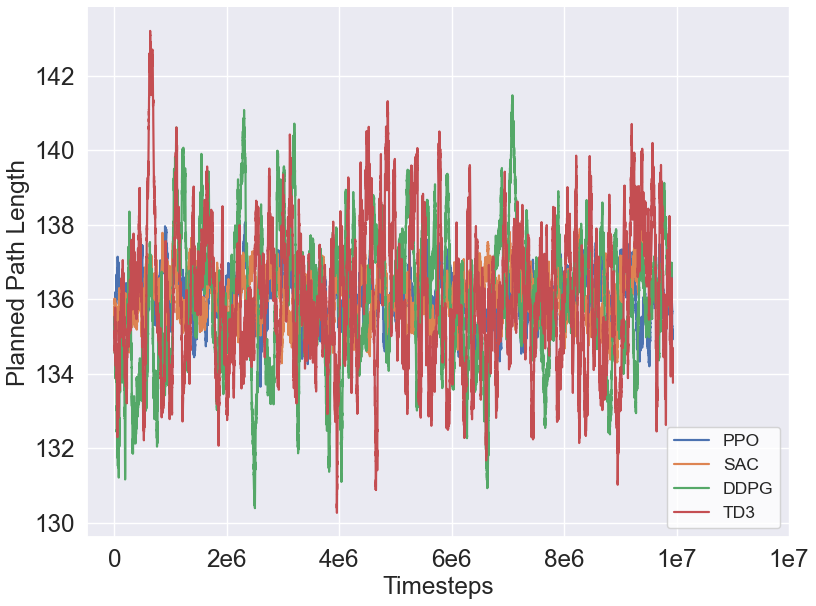

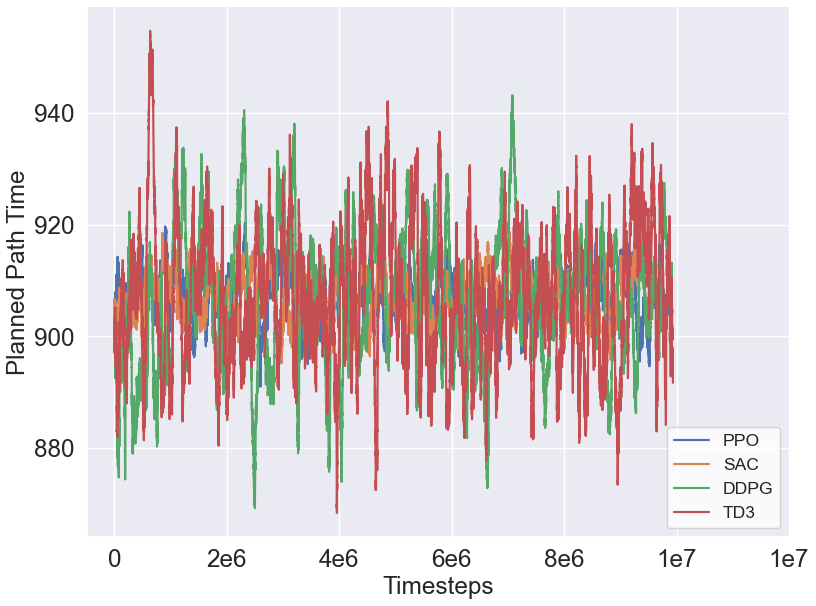

In [25]:
# Parameters
env = "StaticObstacleCREnv-v1"

models = ["PPO", "SAC", "DDPG", "TD3"] # Target environment
features = ['total_reward', 'waypoint_reached', 'crashed', 'average_drift', 'total_intrusion_time', 'intrusion_counter', 'reach_reward', 'drift_reward', 'intrusion_other_ac_reward', 'intrusion_reward', 'average_hdg_action', 'average_spd_action', 'hdg_action_saturated_rate', 'spd_action_saturated_rate', 'average_hdg_action_delta', 'average_spd_action_delta', 'hdg_reversal_rate', 'spd_reversal_rate', 'min_cpa', 'num_encounters', 'min_obstacle_distance', 'num_obstacle_encounters', 'extra_path_length', 'path_length_ratio', 'actual_path_length', 'planned_path_length', 'planned_path_time']

ave_window = 1000
stride = 1  # Set to 1 to keep all points, or higher to reduce the number of points plotted

flag_save_plots = False
flag_show_plots = True

# Set the standard input/output folders
standard_input_folder = f"common/results/logs_backup/{env}/"
output_folder = "../figures_results"

# Set the size of the figure for better visibility in Jupyter Notebook (does not effect the saved PDF)
plt.rcParams['figure.dpi'] = 70

for feature in features:
    figure = make_plots(env, models, feature, labels, ave_window, standard_input_folder, stride=stride)
    show_plots(figure) if flag_show_plots else None
    save_plots(figure, env, models, feature, output_folder) if flag_save_plots else None
    

## Calculate average episode length

In [24]:
# load all models data into a dictionary containing dataframes for each model
data = {}

for model in models:
    data[model] = pd.read_csv(
        f"common/results/logs_backup/{env}/{env}_{model}.csv"
    )

# Calculate episode lengths for each model
for model, df in data.items():
    episode_length = [0] * len(df)

    for index, timesteps in enumerate(df["timesteps"]):
        if index == 0:
            episode_length[index] = timesteps
        else:
            episode_length[index] = timesteps - df["timesteps"][index - 1]

    df["episode_length"] = episode_length


print(f'Timesteps: {data["SAC"]["timesteps"].tolist()}')
print(f"Episode lengths: {data['SAC']['episode_length'].tolist()}")

average_episode_length = np.mean(data['SAC']['episode_length'])


# plot episode lengths for each model
feature = 'episode_length'

output_filename = f"{env}_{all_models}-results_{feature}.pdf"
os.makedirs(output_folder, exist_ok=True)  # Ensure the folder exists
output_path = os.path.join(output_folder, output_filename)

# Set the theme for the plot
sns.set_theme(style="darkgrid")
sns.set_context("talk")

# Initialize the plot
plt.figure(figsize=(12, 9))  # 1200x900 pixels (inches * dpi, assuming 100 dpi)
plt.gca().spines[['right', 'top']].set_visible(False)

# Set specific ticks and font size
plt.xticks([0, 1e6, 2e6], ['0', '1e6', '2e6'], fontsize=25)
plt.yticks(fontsize=25)

# Plot data for each model
for model in models:
    plt.plot(
        data[model]['timesteps'][:-(ave_window - 1)], 
        moving_average(data[model][feature], ave_window), 
        label=model
    )

# Add labels and title with adjusted font size
plt.xlabel('Timesteps', fontsize=25)
plt.ylabel('Episode Length', fontsize=25)
# plt.title(f'Reward Progression in {env}', fontsize=25)

# Adjust legend: larger font size and position in bottom-right corner
legend = plt.legend(
    fontsize=18,  # Increased font size
    loc='lower right',  # Positioned in the bottom-right corner
    frameon=True
)
legend.get_frame().set_facecolor('white')  # White background
# legend.get_frame().set_edgecolor('black')  # Optional: black border

# Save the figure to a PDF file
plt.tight_layout()
plt.savefig(output_path, format='pdf')
# plt.close()  # Close the plot to free memory

print(f"Plot saved as {output_path}")




Timesteps: [100, 200, 230, 255, 355, 451, 551, 579, 679, 779, 879, 979, 1079, 1128, 1175, 1275, 1287, 1387, 1423, 1426, 1526, 1626, 1726, 1785, 1885, 1906, 1941, 1953, 2053, 2153, 2253, 2255, 2264, 2360, 2382, 2467, 2567, 2667, 2762, 2862, 2962, 3062, 3136, 3198, 3223, 3323, 3329, 3429, 3529, 3629, 3729, 3829, 3929, 3938, 4038, 4138, 4238, 4338, 4339, 4360, 4454, 4554, 4654, 4663, 4691, 4754, 4854, 4954, 5054, 5154, 5187, 5287, 5349, 5378, 5453, 5492, 5518, 5618, 5718, 5818, 5918, 5931, 5938, 6038, 6066, 6070, 6170, 6173, 6273, 6373, 6473, 6573, 6673, 6686, 6759, 6859, 6891, 6904, 7004, 7008, 7040, 7140, 7240, 7340, 7342, 7442, 7528, 7541, 7641, 7645, 7745, 7845, 7945, 8045, 8060, 8119, 8219, 8319, 8396, 8496, 8586, 8686, 8786, 8852, 8952, 8954, 8977, 9012, 9112, 9212, 9232, 9332, 9432, 9532, 9632, 9732, 9832, 9932, 10032, 10093, 10115, 10215, 10315, 10370, 10470, 10484, 10504, 10604, 10695, 10795, 10895, 10995, 11095, 11195, 11295, 11395, 11443, 11543, 11643, 11743, 11843, 11886, 1191

NameError: name 'all_models' is not defined

Logs from commit 

This commit has the AI4realnet environemnt with fixed observation vector. It is the starting point for subsequent improvement. 

In [ ]:
# Parameters
env = "StaticObstacleCREnv-v1"

models = ["PPO", "SAC", "DDPG", "TD3"] # Target environment
features = ['total_reward', 'waypoint_reached', 'crashed', 'average_drift', 'total_intrusion_time', 'intrusion_counter', 'reach_reward', 'drift_reward', 'intrusion_other_ac_reward', 'intrusion_reward', 'average_hdg_action', 'average_spd_action', 'hdg_action_saturated_rate', 'spd_action_saturated_rate', 'average_hdg_action_delta', 'average_spd_action_delta', 'hdg_reversal_rate', 'spd_reversal_rate', 'min_cpa', 'num_encounters', 'min_obstacle_distance', 'num_obstacle_encounters', 'extra_path_length', 'path_length_ratio', 'actual_path_length', 'planned_path_length', 'planned_path_time']

ave_window = 1000
stride = 1  # Set to 1 to keep all points, or higher to reduce the number of points plotted

flag_save_plots = True
flag_show_plots = True

# Set the standard input/output folders
standard_input_folder = f"common/results/logs_backup/{env}/"
output_folder = "../figures_results"

# Set the size of the figure for better visibility in Jupyter Notebook (does not effect the saved PDF)
plt.rcParams['figure.dpi'] = 70

for feature in features:
    figure = make_plots(env, models, feature, labels, ave_window, standard_input_folder, stride=stride)
    show_plots(figure) if flag_show_plots else None
    save_plots(figure, env, models, feature, output_folder) if flag_save_plots else None
    